# Regresion Basica: Predecir eficiencia de gasolina

Este libro usa el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) y construye un modelo para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Este ejemplo usa el API `tf.keras` , revise [Esta Guia](https://www.tensorflow.org/guide/keras) para obtener mas detalles.

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

## El set de Datos de MPG

El set de datos esta disponible de el siguiente repositorio [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).

### Obtenga los datos
Primero descargue el set de datos.
keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

In [59]:
dataset_path = keras.utils.get_file(
    "auto-mpg.data",
    "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
)

dataset_path

'C:\\Users\\Asier\\.keras\\datasets\\auto-mpg.data'

Importelo usando pandas.

In [60]:
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin", "Car name"]

In [61]:
raw_dataset = pd.read_csv(
    dataset_path,
    names=column_names,
    na_values="?",
    comment="\t",
    sep="\s+",
    skipinitialspace=True
)

dataset = raw_dataset.copy()
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [62]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   Car name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [63]:
dataset["Car name"].nunique()

305

### Limpia los datos

Trata los missings y variables categóricas

In [64]:
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
Car name        0
dtype: int64

In [65]:
dataset = dataset.dropna()

In [66]:
dataset = dataset.drop(columns=["Car name"])

In [67]:
origin = dataset.pop('Origin')

In [68]:
dataset['USA'] = (origin == 1)*1.0
dataset['Europe'] = (origin == 2)*1.0
dataset['Japan'] = (origin == 3)*1.0

In [69]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           392 non-null    float64
 1   Cylinders     392 non-null    int64  
 2   Displacement  392 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        392 non-null    float64
 5   Acceleration  392 non-null    float64
 6   Model Year    392 non-null    int64  
 7   USA           392 non-null    float64
 8   Europe        392 non-null    float64
 9   Japan         392 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 33.7 KB


### Divide los datos en train y test

Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo.

NOTA: El resultado tienen que ser dos datasets

In [70]:
train_dataset = dataset.sample(frac=0.8,random_state=0)
test_dataset = dataset.drop(train_dataset.index)

### Inspecciona los datos

Revise rapidamente la distribucion conjunta del dataset de entrenamiento mediante un grid de gráficos

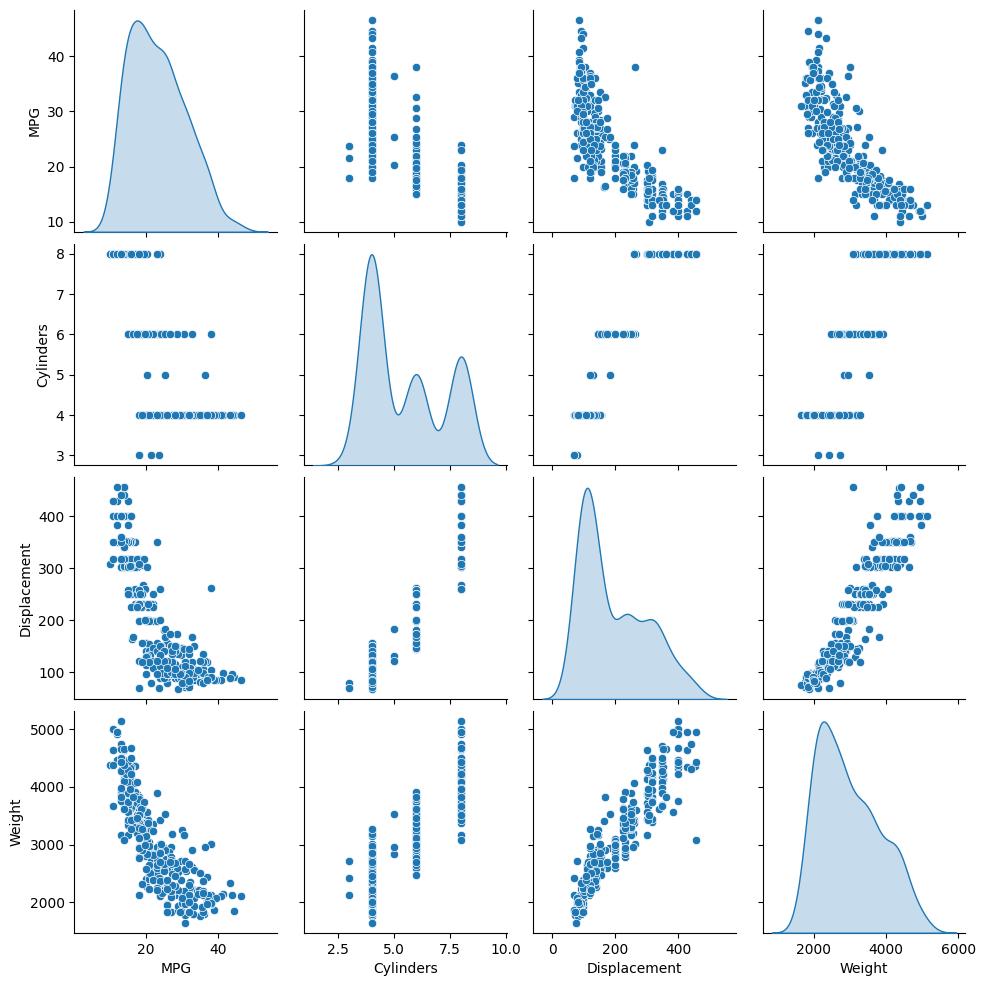

In [71]:
sns.pairplot(train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind="kde")

Tambien revise las estadisticas generales:

In [73]:
train_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0
USA,314.0,0.624204,0.485101,0.0,0.00,1.0,1.00,1.0
Europe,314.0,0.178344,0.383413,0.0,0.00,0.0,0.00,1.0
Japan,314.0,0.197452,0.398712,0.0,0.00,0.0,0.00,1.0


### Separa las features del target

Separe el target de las features.

In [74]:
train_labels = train_dataset.pop('MPG')
test_labels = test_dataset.pop('MPG')

### Estandariza los datos

Es una buena práctica estandarizar funciones que utilizan diferentes escalas y rangos. Aunque el modelo podría converger sin estandarizar, dificulta el entrenamiento y hace que el modelo resultante dependa de la elección de las unidades utilizadas en la entrada.

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_dataset_scaled = scaler.fit_transform(train_dataset)
test_dataset_scaled = scaler.transform(test_dataset)

Estos datos estandarizados es lo que usaremos para entrenar el modelo.

## El modelo

### Construye el modelo

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo.

Por tanto, tendrá tres capas. Una de entrada con activación relu. Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres para las dos primeras capas.

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

In [76]:
import tensorflow as tf

model = keras.models.Sequential([
    keras.layers.Dense(30, activation = 'relu',
                      input_shape = train_dataset_scaled.shape[1:]),
    keras.layers.Dense(1)
])

model.compile(loss = "mse",
            optimizer = tf.keras.optimizers.RMSprop(0.001),
            metrics=["mae", "mse"]
            )

c:\Users\Asier\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Inspeccione el modelo

Use el método `.summary` para imprimir una descripción simple del modelo

In [77]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331 (1.29 KB)

 Trainable params: 331 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo

Entrene el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

NOTA: recuerda usar los datos normalizados.

In [78]:
history = model.fit(train_dataset_scaled,
                   train_labels,
                   epochs = 1000,
                   validation_split = 0.1
)

Epoch 1/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 596.1810 - mae: 23.1938 - mse: 596.1810 - val_loss: 598.3534 - val_mae: 22.8931 - val_mse: 598.3534
Epoch 2/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 584.0560 - mae: 22.9294 - mse: 584.0560 - val_loss: 587.6908 - val_mae: 22.6591 - val_mse: 587.6908
Epoch 3/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 574.5267 - mae: 22.7216 - mse: 574.5267 - val_loss: 577.9432 - val_mae: 22.4433 - val_mse: 577.9432
Epoch 4/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 565.4635 - mae: 22.5232 - mse: 565.4635 - val_loss: 568.4796 - val_mae: 22.2288 - val_mse: 568.4796
Epoch 5/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 556.6391 - mae: 22.3242 - mse: 556.6391 - val_loss: 559.0744 - val_mae: 22.0124 - val_mse: 559.0744
Epoch 6/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 547.7355 - mae: 22.1213 - mse: 547.7355 - val_loss: 549.5828 - val_mae: 21.7925 - val_mse: 549.5828
Epoch 7/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step -

Visualice el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`.

In [84]:
history_df = pd.DataFrame(history.history)
history_df["epoch"] = history.epoch

In [85]:
history_df.tail()

,loss,mae,mse,val_loss,val_mae,val_mse,epoch
995,5.817432,1.683403,5.817432,7.525172,2.154400,7.525172,995
996,5.812183,1.670962,5.812183,7.565060,2.162705,7.565060,996
997,5.826466,1.681468,5.826466,7.394650,2.145750,7.394650,997
998,5.801991,1.675681,5.801991,7.438077,2.148805,7.438077,998
999,5.777789,1.668752,5.777789,7.551119,2.157851,7.551119,999


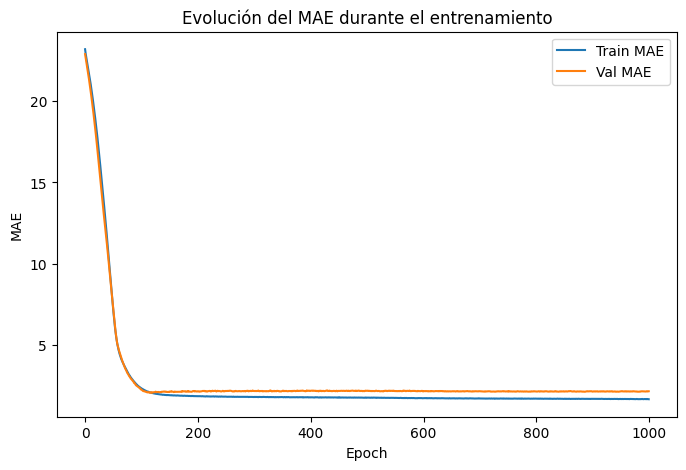

In [86]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["mae"], label="Train MAE")
plt.plot(history_df["epoch"], history_df["val_mae"], label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Evolución del MAE durante el entrenamiento")
plt.show()


¿Alguna conclusión respecto a este gráfico?

A partir de cierto número de epoch el error se estabiliza, por lo que entrenar durante 1000 epochs resulta innecesario.

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

Ahora prueba el modelo. Coge 10 ejemplos de test y llama a` model.predict`.

In [87]:
loss, mae, mse = model.evaluate(
    test_dataset_scaled,
    test_labels,
    verbose=2
)

print(f"Test loss (MSE): {loss}")
print(f"Test MAE: {mae}")
print(f"Test MSE: {mse}")

3/3 - 0s - 28ms/step - loss: 5.2541 - mae: 1.7647 - mse: 5.2541
Test loss (MSE): 5.25408411026001
Test MAE: 1.764662504196167
Test MSE: 5.25408411026001


In [88]:
test_predictions = model.predict(test_dataset_scaled[:10])

test_predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([[15.430628],
       [10.896467],
       [10.151532],
       [23.789871],
       [21.298141],
       [12.807956],
       [13.17548 ],
       [12.491518],
       [18.786093],
       [30.442566]], dtype=float32)

In [89]:
comparison = pd.DataFrame({
    "Real MPG": test_labels.iloc[:10].values,
    "Predicted MPG": test_predictions.flatten()
})

comparison

,Real MPG,Predicted MPG
0,15.0,15.430628
1,10.0,10.896467
2,9.0,10.151532
3,25.0,23.789871
4,19.0,21.298141
5,14.0,12.807956
6,14.0,13.175480
7,13.0,12.491518
8,18.0,18.786093
9,35.0,30.442566


### Haz Predicciones

Dibuja en un scatter plot las predicciones de test vs sus true labels.

In [91]:
test_predictions = model.predict(test_dataset_scaled)
#Aplana predicciones
test_predictions_flat = test_predictions.flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


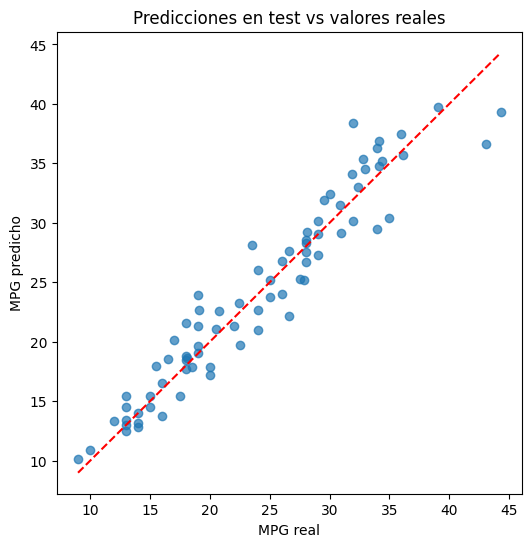

In [92]:
plt.figure(figsize=(6, 6))
plt.scatter(test_labels, test_predictions_flat, alpha=0.7)

# Línea y = x (predicción perfecta)
plt.plot(
    [test_labels.min(), test_labels.max()],
    [test_labels.min(), test_labels.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("MPG real")
plt.ylabel("MPG predicho")
plt.title("Predicciones en test vs valores reales")
plt.show()

Parece que nuestro modelo predice razonablemente bien. Echemos un vistazo a la distribución de errores.

Representa los residuos en un histograma

In [109]:
errors = test_predictions_flat - test_labels.values

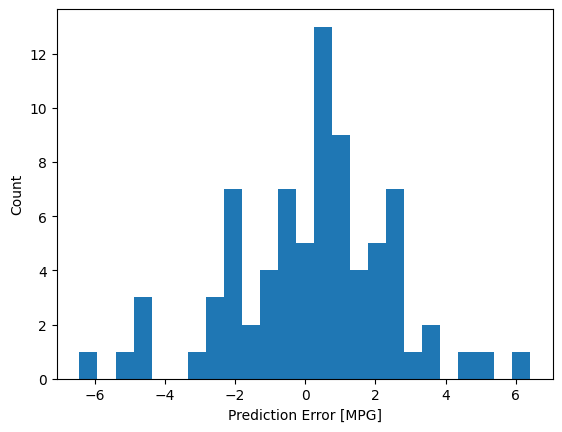

In [110]:
plt.hist(errors, bins = 25)
plt.xlabel("Prediction Error [MPG]")
_ = plt.ylabel("Count")

No es del todo gaussiano, pero podríamos esperar eso porque el número de muestras es muy pequeño.

Guarda tu modelo en un archivo.

In [96]:
model.save("auto_mpg_model.keras")

## Conclusion

En este ejercicio se ha construido un modelo de regresión utilizando una red neuronal con Keras para predecir el consumo de combustible (MPG) a partir de características físicas de los vehículos. Tras dividir correctamente el conjunto de datos en entrenamiento y test, se ha realizado una estandarización de las variables.

El análisis de las predicciones y de la distribución de los residuos sugiere que el modelo no introduce sesgos sistemáticos, aunque existen algunos errores elevados atribuibles al reducido tamaño del conjunto de datos y a la presencia de valores atípicos. En conjunto, los resultados obtenidos son satisfactorios y demuestran que el modelo es capaz de capturar de forma adecuada la relación entre las variables de entrada y el consumo de combustible.